<a href="https://colab.research.google.com/github/NicolasZarateC/Analitica-de-Negocios/blob/main/Gustavo_Petro_Desempleo_An%C3%A1lisis_2022_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Descargar librerias y montar el drive**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk #Natural Language Toolkit
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt_tab') #Optimizador del proceso de Tokenización => (Etapa 1)

from google.colab import drive
drive.mount('/content/drive')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
frase="""El señor Ramírez ha visto un enjambre de abejas acercarse.
Asustado, corrióp como nunca había corrido en su vida. Olvidó que corría
directo al precipicio"""

tok_sent=sent_tokenize(frase)
print(tok_sent)

tok_word=word_tokenize(frase)
print(tok_word)

['El señor Ramírez ha visto un enjambre de abejas acercarse.', 'Asustado, corrióp como nunca había corrido en su vida.', 'Olvidó que corría\ndirecto al precipicio']
['El', 'señor', 'Ramírez', 'ha', 'visto', 'un', 'enjambre', 'de', 'abejas', 'acercarse', '.', 'Asustado', ',', 'corrióp', 'como', 'nunca', 'había', 'corrido', 'en', 'su', 'vida', '.', 'Olvidó', 'que', 'corría', 'directo', 'al', 'precipicio']


In [3]:
!pip install vaderSentiment #Diccionario palabras
!pip install -U spacy #Industrial strenghth natural langauge processing
!spacy download es_core_news_lg #Español
!spacy download en_core_web_sm #Ingles

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sia=SentimentIntensityAnalyzer() #Analizador de sentimientos

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.0/33.0 MB 36.6 MB/s eta 0:00:00
  Attempting uninstall: spacy
    Found existing installation: spacy 3.8.5
    Uninstalling spacy-3.8.5:
      Successfully uninstalled spacy-3.8.5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 3.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 107.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to r

In [4]:
for txtw in tok_word:
  print(txtw,sia.polarity_scores(txtw))

El {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
señor {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Ramírez {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
ha {'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.34}
visto {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
un {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
enjambre {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
de {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
abejas {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
acercarse {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
. {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Asustado {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
, {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
corrióp {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
como {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
nunca {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
había {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'c

In [5]:
for tok_sent in tok_sent:
  print(tok_sent,sia.polarity_scores(tok_sent))

El señor Ramírez ha visto un enjambre de abejas acercarse. {'neg': 0.0, 'neu': 0.789, 'pos': 0.211, 'compound': 0.34}
Asustado, corrióp como nunca había corrido en su vida. {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Olvidó que corría
directo al precipicio {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}


**Base de Datos**

Para la elaboración de este código, la base de datos utilizada  corresponde a una recopilación documental de los discursos oficiales pronunciados por el presidente Gustavo Petro relacionados con el desempleo en Colombia, durante su periodo de gobierno que abarca desde agosto de 2022 hasta mayo de 2025.

Los documentos fueron extraídos del sitio web oficial de la Presidencia de la República de Colombia y organizados cronológicamente por año en archivos de texto.

**Variables**

En este modelo se utilizaron once variables de sentimientos que permiten clasificar los discursos en diferentes categorías emocionales. Algunas de estas variables son más negativas que otras, por ejemplo, ‘Amenaza’ refleja situaciones de peligro o riesgo social, mientras que otras como ‘Optimismo’ o ‘Confianza’ expresan emociones positivas. Para poder analizarlas de forma cuantitativa, a cada variable se le asignó un valor numérico en una escala que va de -1.0 (muy negativa) a 1.0 (muy positiva). Esto permite convertir las emociones cualitativas de los discursos en datos medibles y comparables.

**Comentarios Neutros**

Es importante entender que en estos discursos se encuentran muchos comentarios neutros. Es más, la mayoría de las frases tienen resultados muy cercanos a 0 (neutros). El presidente expone cifras, reporta avances o presenta contextos de manera neutral, sin utilizar palabras que transmitan una carga afectiva fuerte, ya sea positiva o negativa y por eso se le atribuye este sentimiento a los comentarios de este estilo.

**Informe 2022**

In [7]:
nxl= '/content/drive/MyDrive/Eafit/Colab Notebooks - Analítica de Negocios/Proyecto Final/2022_Desempleo_Petro.txt'
ntx=open(nxl,encoding='utf-8').read()
print(ntx)

#Se estalbece la escala de sentimientos numero a cualitativo

#Escalas PANAS [Positive and Negative Affective Scale]
vn=['Amenaza', 'Pesimismo','Inestabilidad','Escepticismo', 'Indiferente',
    'Neutral', 'Favorable','Optimismo', 'Convicción', 'Consolidación',
    'Confianza']
vnm=np.array([-1.0,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1.0])

sent_tk=sent_tokenize(ntx)
print(sent_tk)

#Evitar palabras indeseables creando un documento
import spacy
nlp=spacy.load('es_core_news_lg')
doc=nlp(ntx)
oraciones=[sent.text for sent in doc.sents]

resultados=[]
for txtm in oraciones:
  print(txtm)
  scores=sia.polarity_scores(txtm)
  print(scores)
  print("La polaridad es:", scores['compound'])

  #A que setimiento pertenece el compound
  d=np.abs(vnm-scores['compound'])
  categoria=np.where(d==min(d))[0][0]
  print(vn[categoria])
  resultados.append([txtm,scores['compound'],vn[categoria]])

#Se crea el informe
df=pd.DataFrame(resultados,columns=['oracion','compound','sentimiento'])
df.head(100)
df.to_excel('Informe2022.xlsx')

El empleo industrial, sobre todo en confecciones y calzado, va bien.

La cifra de desempleo está en un dígito respecto a la economía formal, la del capital. Es buena noticia y el año entrante debe disminuir aún más. El empleo industrial, sobre todo en confecciones y calzado, va bien.

Nos mantenemos en una tasa de desempleo de un solo dígito para noviembre de 2022. Esto sigue demostrando una recuperación del mercado laboral y ya comienzan a retomarse los valores que teníamos antes de la pandemia.

¿Qué elementos, podríamos llamar positivos, aparecen en el escenario actual en la economía colombiana?
Yo he visto tres. Pueden ser más, claro. Indudablemente baja la tasa de desempleo en Colombia. Es un indicador objetivo, para mí, el principal indicador que se debe tener en cuenta en la valoración de un sistema económico es su capacidad de empleo. Este indicador no está funcionando mal, es probable que para el año entrante no funcione mal, sobre todo si podemos implementar políticas anti cí

**Analisis de resultados informe 2022:**

En 2022, el discurso del presidente Petro sobre el desempleo refleja escepticismo e indiferencia, con predominio de neutralidad. Aunque se reconocieron avances puntuales, persistieron dudas sobre la sostenibilidad de los logros y los retos estructurales del mercado laboral, evidenciando una postura cautelosa ante los cambios observados.

**Informe 2023**

In [8]:
nxl= '/content/drive/MyDrive/Eafit/Colab Notebooks - Analítica de Negocios/Proyecto Final/2023_Desempleo_Petro.txt'
ntx=open(nxl,encoding='utf-8').read() #El archivo mas simple utf-8
print(ntx)

#Se estalbece la escala de sentimientos numero a cualitativo
#Escalas PANAS [Positive and Negative Affective Scale]
vn=['Amenaza', 'Pesimismo','Inestabilidad','Escepticismo', 'Indiferente',
    'Neutral', 'Favorable','Optimismo', 'Convicción', 'Consolidación',
    'Confianza']
vnm=np.array([-1.0,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1.0])

sent_tk=sent_tokenize(ntx)
print(sent_tk)

#Evitar palabras indeseables creando un documento
import spacy
nlp=spacy.load('es_core_news_lg')
doc=nlp(ntx)
oraciones=[sent.text for sent in doc.sents]

resultados=[]
for txtm in oraciones:
  print(txtm)
  scores=sia.polarity_scores(txtm)
  print(scores)
  print("La polaridad es:", scores['compound'])

  #A que setimiento pertenece el compound
  d=np.abs(vnm-scores['compound'])
  categoria=np.where(d==min(d))[0][0]
  print(vn[categoria])
  resultados.append([txtm,scores['compound'],vn[categoria]])

#Se crea el informe
df=pd.DataFrame(resultados,columns=['oracion','compound','sentimiento'])
df.head(100)
df.to_excel('Informe2023.xlsx')

Redujimos el desempleo a un dígito y hoy, con un 9% de desocupados, tenemos una de las tasas más bajas en el siglo que llevamos recorrido.

En el año 2023 logramos un incremento del salario mínimo nominal de más de 16%, lo cual significó un incremento de 6,5% del salario mínimo real. Absorbimos la caída que le dejó Duque y aumentamos 3 puntos más.

Este año hemos aumentado el salario mínimo nominal un 12,5%. Aspiramos a final de año que gane otros 6 puntos reales, porque disminuiremos aún más la inflación de precios.

Esto significa que, en dos años de Gobierno, habríamos elevado el nivel de vida de las 2 millones y medio de familias que ganan un salario mínimo y millones más que son jalonadas por él, un 12%.

Colombia no había visto eso antes y se enmarca en nuestra política de erradicación de la pobreza y de disminución de las desigualdades.
Hemos firmado el decreto de liquidación del presupuesto del 2024. Allí inicia en forma generalizada la construcción de sedes de educación superi

**Analisis de resultados informe 2023:**

En 2023, el análisis de 18 frases del discurso presidencial muestra un aumento de emociones positivas como Optimismo (3) y Convicción (2) , reflejadas claramente en el gráfico spider plot. A diferencia de 2022, donde predominaban la neutralidad y el escepticismo, el discurso actual afirma logros laborales y busca generar confianza.

**Informe 2024**

In [9]:
nxl= '/content/drive/MyDrive/Eafit/Colab Notebooks - Analítica de Negocios/Proyecto Final/2024_Desempleo_Petro.txt'
ntx=open(nxl,encoding='utf-8').read() #El archivo mas simple utf-8
print(ntx)

#Se estalbece la escala de sentimientos numero a cualitativo
#Escalas PANAS [Positive and Negative Affective Scale]
vn=['Amenaza', 'Pesimismo','Inestabilidad','Escepticismo', 'Indiferente',
    'Neutral', 'Favorable','Optimismo', 'Convicción', 'Consolidación',
    'Confianza']
vnm=np.array([-1.0,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1.0])

sent_tk=sent_tokenize(ntx)
print(sent_tk)

#Evitar palabras indeseables creando un documento
import spacy
nlp=spacy.load('es_core_news_lg')
doc=nlp(ntx)
oraciones=[sent.text for sent in doc.sents]

resultados=[]
for txtm in oraciones:
  print(txtm)
  scores=sia.polarity_scores(txtm)
  print(scores)
  print("La polaridad es:", scores['compound'])

  #A que setimiento pertenece el compound
  d=np.abs(vnm-scores['compound'])
  categoria=np.where(d==min(d))[0][0]
  print(vn[categoria])
  resultados.append([txtm,scores['compound'],vn[categoria]])

#Se crea el informe
df=pd.DataFrame(resultados,columns=['oracion','compound','sentimiento'])
df.head(100)
df.to_excel('Informe2024.xlsx')

Hemos cerrado este año con mucha ilusión y cada vez más convencidos de que este es el camino para construir una Colombia justa y en paz.

Solo en el año 2023 su administración sacó a 2,5 millones de personas del hambre en Colombia, “una cifra que nos alegra el corazón y nos impulsa a seguir avanzando.

En ese mismo año, 2023, habíamos logrado sacar de la pobreza monetaria, según el DANE, a 1 millón 600 mil personas y a 1 millón 100 mil personas de la pobreza extrema en el primer año de gobierno.

En octubre, el DANE reportó un crecimiento de 2,9% real de la economía. Veníamos de cero. Estamos creciendo efectivamente en Colombia. 

No crecemos porque creció el precio del petróleo, porque sacamos más petróleo del subsuelo o carbón. Crecemos porque hay más agricultura, porque hay más industria, porque hay más producción, y lo que hace rico a un país, a una sociedad, es la producción.

El aumento de la producción contribuyó a la reducción del desempleo a 8,2%, según la última medición de n

**Analisis de resultados informe 2024:**

En el 2024, el presidente empieza de forma muy positivas su discurso y concluye de forma muy neutral. Al principio del discurso encontramos en las primeras dos frases un sentimiento de convicción con el compound más alto que se encuentra en todos estos años (0.543) y le siguen comentarios con sentimientos favorables y de optimismo.

**Informe 2025**

In [10]:
nxl= '/content/drive/MyDrive/Eafit/Colab Notebooks - Analítica de Negocios/Proyecto Final/2025_Desempleo_Petro.txt'
ntx=open(nxl,encoding='utf-8').read() #El archivo mas simple utf-8
print(ntx)

#Se estalbece la escala de sentimientos numero a cualitativo
#Escalas PANAS [Positive and Negative Affective Scale]
vn=['Amenaza', 'Pesimismo','Inestabilidad','Escepticismo', 'Indiferente',
    'Neutral', 'Favorable','Optimismo', 'Convicción', 'Consolidación',
    'Confianza']
vnm=np.array([-1.0,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1.0])

sent_tk=sent_tokenize(ntx)
print(sent_tk)

#Evitar palabras indeseables creando un documento
import spacy
nlp=spacy.load('es_core_news_lg')
doc=nlp(ntx)
oraciones=[sent.text for sent in doc.sents]

resultados=[]
for txtm in oraciones:
  print(txtm)
  scores=sia.polarity_scores(txtm)
  print(scores)
  print("La polaridad es:", scores['compound'])

  #A que setimiento pertenece el compound
  d=np.abs(vnm-scores['compound'])
  categoria=np.where(d==min(d))[0][0]
  print(vn[categoria])
  resultados.append([txtm,scores['compound'],vn[categoria]])

#Se crea el informe
df=pd.DataFrame(resultados,columns=['oracion','compound','sentimiento'])
df.head(100)
df.to_excel('Informe2025.xlsx')

La tasa de desempleo no solo ha bajado a un dígito, sino, que respecto a un año, ha bajado sustancialmente, casi 2 puntos. Una caída sustancial.

Es uno de los éxitos más grandes del gobierno del cambio.

No es por azar. El éxito en caída del desempleo tiene que ver con el nuevo criterio de desarrollo que defendí desde campaña.

Por pereza y oportunismo de la oligarquía, desde hace tres décadas, se puso toda la política económica al servicio de la extracción de petróleo y carbón, y estas ramas se convirtieron en el principal sector exportador, un 60% de divisas, todas las demás ramas económicas empezaron a morir y el país se terminó especializando en las ramas del boom exportador: petróleo, carbón y cocaína, tal como predice la teoría económica, en su teorema de la "enfermedad holandesa".

Si la actividad del petróleo y el carbón, es de baja intensidad de trabajo, y las ramas que se detuvieron son de alta intensidad de trabajo, lo que hizo el modelo de desarrollo extractivista fue dest

**Analisis de resultados informe 2025:**

Este año vemos que el discurso es el más negativo de todos, aún asi los resultados no sean malos. El presidente habla mucho de cosas negativas alrededor del desempleo y por eso es que encontramos durante todo el discurso muchos sentimientos de inestablididad (2) y indiferencia (4). Además, el discurso termina de una forma negativa con un comentario de pesimismo con un compound muy negativo de -0.743.

**Comparación Resultados 2022-2025:**

Comparando los resultados con el modelo de analisis de sentimientos entre los años 2022 hasta 2025, vemos ciertos cambios sobre el sentimiento que se le encuentra al presidente cuando habla sobre el desempleo. Vemos que en general en el 2022 vemos que se le va dando una connotación más neutral al asunto con una mayoria de comentariso indiferentes (4) y neutrales (3). Despues, vemos que en el 2023 hay un cambio a un tono un poco más positivo con una mayoria de comentarios con sentimientos de optimismo (3) e incluso de convicción (2). En el 2024, el presidente hace comentarios muy neutros pero igual sigue positivo, incluso empieza el discurso con un comentario el cual tiene el compound más alto de todo los discursos analizados con 0.543 de convicción. El 2025 si termina dando un giro interesante de forma negativa, siendo un discurso el cual dice que en temas de desempleo el país no va necesariamente mal, pero lo presenta de una forma muy negativa hablando de muchas cosas que estaban y están mal en el país. Además, este año encontramos el comentario más negativo, con un compound de -0.743 atribuido al sentimiento de pesimismo que incluso se encuentra en la última frase de discurso.

En conclusión, vemos que el sentimiento alrededor del desempleo tiene muchos comentarios neutros ya que el presidente presenta muchos datos estadisticos y cifras, pero, igual le atribuye sentimientos positivos generalmente a su rendición de cuentas sobre su trabajo. Encontramos además muchos sentimientos negativos, pero se encuentran cuando se habla sobre la presidencia pasada o sobre los años pasados antes de que el llegara al cargo.

Debajo se encuentra un histograma de frecuencias y un spider plot consolidado con los sentimientos de los 4 años de discursos para su debida comparación de los sentimientos encontrados en cada discurso.

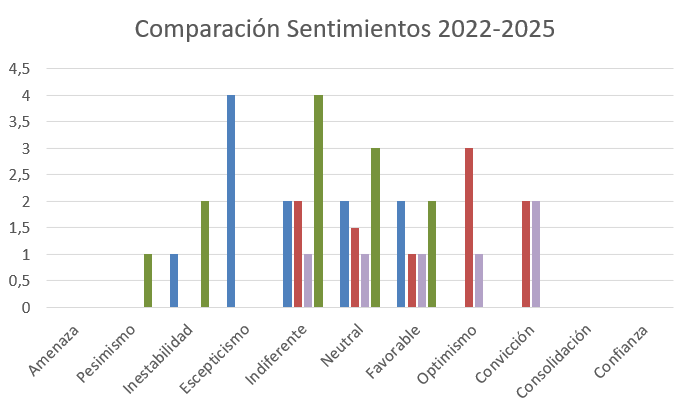

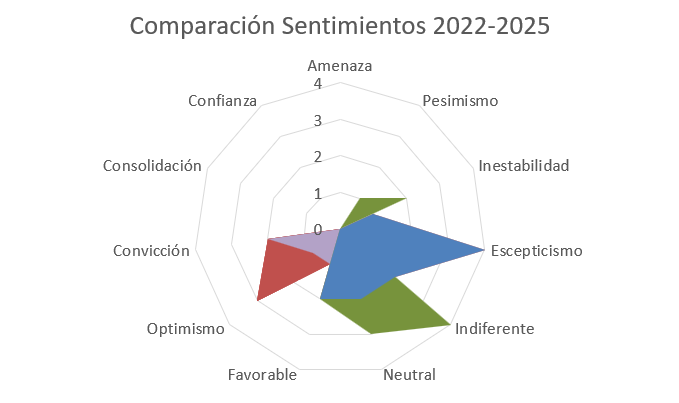